# Two-Mode Regression (Interactive)

Generate the synthetic two-regime dataset in memory and run OLS with `statsmodels` for:
- pooled data
- mode 1 only
- mode 2 only


In [1]:
import sys
from pathlib import Path

# Make import robust whether notebook is launched from repo root or this folder
sys.path.append(str(Path.cwd()))
sys.path.append(str(Path.cwd() / "hkdis" / "voleon"))

import numpy as np

try:
    import statsmodels.api as sm
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("Install statsmodels in this kernel: %pip install statsmodels") from exc

from gen_ortho import generate_two_mode_canceling


In [2]:
def fit_ols(X, y):
    """Fit OLS with intercept and return a statsmodels results object."""
    X_ = sm.add_constant(X, has_constant="add")
    return sm.OLS(y, X_).fit()


In [3]:
# Parameters (edit freely)
n1 = 750
n2 = 250
p = 10
target_r2 = 0.2
sep = 5.0
seed = 7

X, y, mode, diag = generate_two_mode_canceling(
    n1=n1,
    n2=n2,
    p=p,
    target_r2=target_r2,
    sep=sep,
    seed=seed,
)

X1, y1 = X[mode == 1], y[mode == 1]
X2, y2 = X[mode == 2], y[mode == 2]

diag


{'r2_mode1': 0.19999999999999996,
 'r2_mode2': 0.19999999999999996,
 'r2_pooled': -2.220446049250313e-16}

In [4]:
pooled = fit_ols(X, y)
print("Pooled regression: y ~ X")
print(pooled.summary())


Pooled regression: y ~ X
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.010
Method:                 Least Squares   F-statistic:                     0.000
Date:                Sun, 01 Mar 2026   Prob (F-statistic):               1.00
Time:                        12:45:43   Log-Likelihood:                -3741.3
No. Observations:                1000   AIC:                             7505.
Df Residuals:                     989   BIC:                             7559.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.053e-15      

In [ ]:
reg1 = fit_ols(X1, y1)
print("Mode 1 regression: y ~ X | mode=1")
print(reg1.summary())


In [ ]:
reg2 = fit_ols(X2, y2)
print("Mode 2 regression: y ~ X | mode=2")
print(reg2.summary())


In [10]:
import pandas as pd
dfX = pd.DataFrame(X)
dfX.describe()


,0,1,2,3,4,5,6,7,8,9
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.612338,1.162148,-2.499540,-1.806690,0.481720,1.581922,0.579802,0.378293,-0.382986,-0.039528
std,1.443612,0.967173,2.162088,2.181464,1.219646,1.176460,1.005435,2.024627,1.244768,1.024347
min,-6.082946,-1.978159,-7.721671,-7.105580,-3.252197,-1.617733,-2.470812,-5.276127,-3.519412,-2.966911
25%,-1.321775,0.520551,-4.151290,-3.362236,-0.328655,0.785881,-0.091963,-1.160569,-1.301924,-0.700391
50%,-0.297382,1.168310,-2.852773,-2.259557,0.456571,1.545170,0.514208,0.682064,-0.492794,-0.053998
75%,0.387876,1.817168,-0.723824,-0.395086,1.302211,2.365317,1.143241,1.872455,0.407911,0.601452
max,2.214093,4.693837,3.059374,4.281172,3.818025,5.837033,5.833840,6.257486,3.677146,4.252793


In [11]:
import sklearn as sk 
influence = pooled.get_influence()
cooks_d = influence.cooks_distance[0]
leverage = influence.hat_matrix_diag


In [16]:
dfI = influence.summary_frame()
dfI.sort_values("cooks_d", ascending=False).head(20)

,dfb_const,dfb_x1,dfb_x2,dfb_x3,dfb_x4,dfb_x5,dfb_x6,dfb_x7,dfb_x8,dfb_x9,dfb_x10,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
801,-0.145513,0.130902,0.013533,0.081894,-0.220083,0.295432,0.295515,0.112343,-0.236364,0.223871,0.010182,0.038684,4.757227,0.018455,0.652321,4.810175,0.659582
885,0.105121,0.316424,0.084407,-0.038909,0.303698,-0.331456,0.139153,-0.191096,0.026170,-0.215328,0.214703,0.037609,-4.419891,0.020738,-0.643198,-4.461943,-0.649318
767,0.205515,-0.099551,-0.138942,0.128811,-0.137359,-0.055023,-0.459167,0.134235,0.195521,0.004004,-0.013093,0.031460,-3.932372,0.021890,-0.588273,-3.961475,-0.592627
884,0.030297,-0.202172,0.118182,-0.112777,0.248295,0.023720,-0.041880,-0.279847,0.005776,-0.246119,-0.276715,0.030967,3.204025,0.032116,0.583639,3.219156,0.586396
943,0.138923,0.285419,-0.260297,-0.140937,0.176160,-0.150254,0.045510,-0.057426,-0.138969,-0.051323,-0.156887,0.030959,-4.300705,0.018079,-0.583562,-4.339298,-0.588799
768,-0.214469,-0.078526,0.188033,-0.267350,0.209652,-0.114379,0.241413,-0.055011,-0.094125,0.065240,0.179582,0.028397,3.105713,0.031369,0.558898,3.119392,0.561360
783,0.097894,-0.059969,0.019840,-0.065315,0.069412,-0.041646,-0.294684,-0.143691,0.258957,0.091716,0.279503,0.028366,-4.256047,0.016934,-0.558588,-4.293394,-0.563490
788,-0.004330,-0.078434,-0.087153,-0.168607,0.109649,0.238502,-0.091221,0.251448,-0.054846,0.109236,0.139558,0.027122,4.965421,0.011956,0.546203,5.025953,0.552862
951,0.103503,-0.001744,-0.232325,0.011113,0.000754,0.075454,-0.093794,-0.113206,-0.100240,-0.246718,-0.346904,0.027015,-3.426929,0.024679,-0.545129,-3.445715,-0.548117
936,-0.005751,0.442374,0.027120,-0.008219,-0.022867,-0.047033,0.176668,-0.040500,-0.066624,0.243915,0.095161,0.026924,-3.512329,0.023444,-0.544208,-3.532655,-0.547357


In [28]:
dfI.loc[dfI.cooks_d.abs() > 4/1000]

,dfb_const,dfb_x1,dfb_x2,dfb_x3,dfb_x4,dfb_x5,dfb_x6,dfb_x7,dfb_x8,dfb_x9,dfb_x10,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
750,-0.004953,-0.143735,0.250127,-0.037106,0.083031,-0.017698,-0.100092,-0.157047,0.064794,0.013877,0.032403,0.014451,3.371100,0.013795,0.398700,3.388922,0.400808
752,-0.091893,0.084467,-0.135997,-0.129575,0.032769,0.122691,0.148894,-0.059425,-0.170977,-0.051217,-0.107579,0.008485,-2.218505,0.018610,-0.305504,-2.222921,-0.306112
761,-0.050735,-0.103252,-0.012760,-0.088347,0.061978,0.004941,-0.200598,0.198168,0.079829,-0.153078,0.047704,0.012368,-3.072499,0.014206,-0.368840,-3.085707,-0.370425
762,0.091786,0.119364,-0.008220,0.007821,0.136624,-0.165118,0.121734,-0.006999,-0.072185,-0.097778,0.063550,0.007100,2.317605,0.014332,0.279468,2.322749,0.280089
767,0.205515,-0.099551,-0.138942,0.128811,-0.137359,-0.055023,-0.459167,0.134235,0.195521,0.004004,-0.013093,0.031460,-3.932372,0.021890,-0.588273,-3.961475,-0.592627
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
978,0.038007,-0.051459,0.006065,-0.084205,0.249351,0.134850,0.073839,-0.026566,-0.039347,-0.189498,0.030415,0.018468,4.709854,0.009075,0.450724,4.761170,0.455634
987,-0.162952,-0.145603,0.067058,-0.037963,-0.104026,0.036711,-0.029001,0.020601,0.051086,0.028642,0.024042,0.004676,-2.206071,0.010459,-0.226802,-2.210401,-0.227247
990,-0.068094,-0.043560,0.142315,0.056442,-0.123546,-0.002772,-0.050228,-0.090281,0.078084,0.096590,-0.008165,0.005040,-1.840341,0.016106,-0.235461,-1.842568,-0.235746
995,0.043185,-0.002747,-0.041770,0.109015,-0.165227,0.004912,-0.117313,0.007807,0.075694,0.085772,0.010916,0.006691,-2.283409,0.013920,-0.271295,-2.288294,-0.271876


In [23]:
hat = pd.Series(influence.hat_matrix_diag, name="leverage")
hat

0      0.009354
1      0.004587
2      0.011610
3      0.008718
4      0.007030
         ...   
995    0.013920
996    0.018417
997    0.008816
998    0.020768
999    0.011574
Name: leverage, Length: 1000, dtype: float64

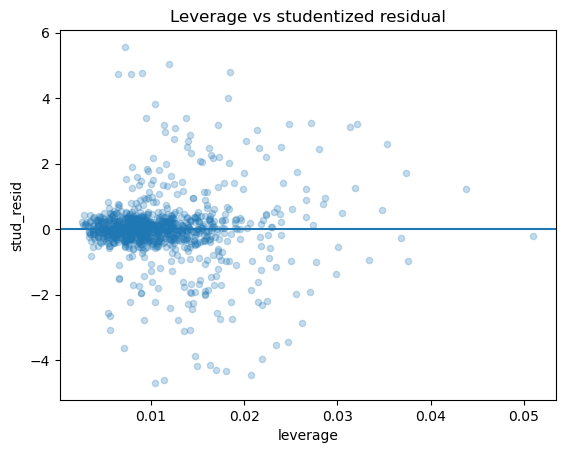

In [25]:
stud = pd.Series(influence.resid_studentized_external, name="stud_resid")
l_res =pd.DataFrame({"leverage": hat, "stud_resid": stud})
plt = l_res.plot.scatter("leverage","stud_resid", alpha=0.25, title="Leverage vs studentized residual")

plt.axhline(0)


In [ ]:
from sklearn.cluster import KMeans
labels = KMeans(2, random_state=0).fit_predict(X)
pd.DataFrame({"pred": pred, "y": y, "grp": labels}).plot.scatter(
    "pred","y", c="grp", colormap="tab10", alpha=0.3
)


In [32]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error

# X: DataFrame/ndarray (n x p)
# y: Series/ndarray (n,)
# mode: optional Series/ndarray with values {1,2} for regime-specific fits

def fit_pls_cv(X, y, max_components=None, n_splits=5, random_state=42):
    X = np.asarray(X)
    y = np.asarray(y).ravel()

    p = X.shape[1]
    max_components = min(p, X.shape[0] - 1) if max_components is None else min(max_components, p, X.shape[0] - 1)

    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rows = []

    for n_comp in range(1, max_components + 1):
        pls = PLSRegression(n_components=n_comp, scale=True)
        y_cv = cross_val_predict(pls, X, y, cv=cv).ravel()
        rows.append({
            "n_components": n_comp,
            "cv_r2": r2_score(y, y_cv),
            "cv_rmse": mean_squared_error(y, y_cv),
        })

    scores = pd.DataFrame(rows).sort_values("cv_r2", ascending=False).reset_index(drop=True)
    best_n = int(scores.loc[0, "n_components"])

    best_model = PLSRegression(n_components=best_n, scale=True).fit(X, y)
    y_hat = best_model.predict(X).ravel()

    return {
        "model": best_model,
        "scores": scores,
        "best_n_components": best_n,
        "train_r2": r2_score(y, y_hat),
        "train_rmse": mean_squared_error(y, y_hat),
    }

# ---- pooled PLS ----
pooled = fit_pls_cv(X, y, max_components=10)
print("Pooled best n_components:", pooled["best_n_components"])
print("Pooled CV top rows:\n", pooled["scores"].head())
print("Pooled train R2:", pooled["train_r2"])

Pooled best n_components: 1
Pooled CV top rows:
    n_components     cv_r2     cv_rmse
0             1 -0.018582  105.974220
1             2 -0.026798  106.829024
2             3 -0.030107  107.173239
3             4 -0.030851  107.250665
4             5 -0.030975  107.263599
Pooled train R2: -2.220446049250313e-16


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans

# Use your custom estimator (ClusterThenRegress) as the model
param_grid = {'clustering__n_clusters': [2, 3, 4, 5]}
grid = GridSearchCV(
    ClusterThenRegress(clustering=KMeans(), regressor=LinearRegression()),
    param_grid,
    cv=5,
    scoring='r2'          # or 'neg_mean_squared_error'
)
grid.fit(X_train, y_train)
print("Best number of clusters:", grid.best_params_)

In [33]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score

class GMMInteractionFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=2, drop_first=True, random_state=7):
        self.n_components = n_components
        self.drop_first = drop_first
        self.random_state = random_state

    def fit(self, X, y=None):
        self.gmm_ = GaussianMixture(
            n_components=self.n_components,
            covariance_type="full",
            random_state=self.random_state,
        ).fit(X)
        return self

    def transform(self, X):
        X = np.asarray(X)
        P = self.gmm_.predict_proba(X)  # soft regime probs
        if self.drop_first and self.n_components > 1:
            P = P[:, 1:]  # avoid perfect collinearity
        inter = np.hstack([X * P[:, [k]] for k in range(P.shape[1])]) if P.shape[1] else np.empty((len(X), 0))
        return np.hstack([X, P, inter])

# X, y from your generator
pipe = Pipeline([
    ("scale", StandardScaler()),
    ("regime_feats", GMMInteractionFeatures(n_components=2, drop_first=True, random_state=7)),
    ("reg", Ridge(alpha=1.0)),
])

cv = KFold(n_splits=5, shuffle=True, random_state=7)
r2 = cross_val_score(pipe, X, y, cv=cv, scoring="r2")
print("CV R^2:", r2, "mean:", r2.mean())

pipe.fit(X, y)
y_hat = pipe.predict(X)


CV R^2: [ 0.08535254  0.17707526  0.15724315 -0.01748889  0.15262999] mean: 0.11096241125175343


In [35]:
y_hat.shape

(1000,)

In [36]:
r2_score(y, y_hat)

0.19213442894718835

In [42]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor

from gen_ortho import generate_two_mode_canceling

# 1) Generate data in memory
X, y, mode, diag = generate_two_mode_canceling(
    n1=7500, n2=2500, p=10, target_r2=0.2, sep=5.0, seed=7
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2) XGBoost config tuned for low-dim (10 features) regime-like structure
xgb = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    n_estimators=2000,       # large upper bound; early stopping will cut it
    learning_rate=0.03,
    max_depth=3,             # piecewise structure, avoid deep trees
    min_child_weight=8,
    subsample=0.85,
    colsample_bytree=1.0,    # with only 10 features, keep all features per tree
    reg_alpha=0.05,
    reg_lambda=2.0,
    early_stopping_rounds=100,
    random_state=42,
)


# xgb = XGBRegressor(
#     objective="reg:squarederror",
#     eval_metric="rmse",
# )

# 3) Fit with validation for early stopping
xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

# 4) Evaluate
pred = xgb.predict(X_test)
# print("Best iteration:", xgb.best_iteration)
print("Train R2:", r2_score(y_train, xgb.predict(X_train)))
print("Test R2:", r2_score(y_test, pred))
print("Test RMSE:", mean_squared_error(y_test, pred))


Train R2: 0.3426127602774036
Test R2: 0.14693774749591704
Test RMSE: 24.179869520707502


In [45]:
# Random Forest on the in-memory two-mode dataset (single notebook cell)

from pathlib import Path
import sys
import numpy as np

# Ensure import works if notebook is launched from repo root or hkdis/voleon
sys.path.append(str(Path.cwd()))
sys.path.append(str(Path.cwd() / "hkdis" / "voleon"))

from gen_ortho import generate_two_mode_canceling

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

# 1) Generate data in memory
X, y, mode, diag = generate_two_mode_canceling(
    n1=7500, n2=2500, p=10, target_r2=0.2, sep=5.0, seed=7
)

# 2) Train/test split (stratify by mode)
X_train, X_test, y_train, y_test, mode_train, mode_test = train_test_split(
    X, y, mode, test_size=0.2, random_state=7, stratify=mode
)

# 3) RandomForest tuned for low-dimensional tabular data (p=10)
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=3,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features=1.0,
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=7,
)

rf.fit(X_train, y_train)

# 4) Predictions + metrics
pred_train = rf.predict(X_train)
pred_test = rf.predict(X_test)

def reg_metrics(y_true, y_pred):
    return {
        "r2": r2_score(y_true, y_pred),
        "rmse": mean_squared_error(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
    }

m_train = reg_metrics(y_train, pred_train)
m_test = reg_metrics(y_test, pred_test)

print("Generation diagnostics:", diag)
print("\nOverall metrics")
print(f"Train -> R2: {m_train['r2']:.4f} | RMSE: {m_train['rmse']:.4f} | MAE: {m_train['mae']:.4f}")
print(f"Test  -> R2: {m_test['r2']:.4f} | RMSE: {m_test['rmse']:.4f} | MAE: {m_test['mae']:.4f}")
print(f"OOB   -> R2: {rf.oob_score_:.4f}")

print("\nPer-mode test metrics")
for m in [1, 2]:
    idx = mode_test == m
    mm = reg_metrics(y_test[idx], pred_test[idx])
    print(f"Mode {m} -> R2: {mm['r2']:.4f} | RMSE: {mm['rmse']:.4f} | MAE: {mm['mae']:.4f} | n={idx.sum()}")

print("\nFeature importances")
for i, val in enumerate(rf.feature_importances_, start=1):
    print(f"x{i}: {val:.4f}")


Generation diagnostics: {'r2_mode1': 0.20000000000000007, 'r2_mode2': 0.20000000000000007, 'r2_pooled': 0.0}

Overall metrics
Train -> R2: 0.0984 | RMSE: 24.8557 | MAE: 3.0477
Test  -> R2: 0.0555 | RMSE: 25.8786 | MAE: 3.0854
OOB   -> R2: 0.0568

Per-mode test metrics
Mode 1 -> R2: 0.0051 | RMSE: 3.7919 | MAE: 1.5491 | n=1500
Mode 2 -> R2: 0.0600 | RMSE: 92.1386 | MAE: 7.6944 | n=500

Feature importances
x1: 0.0477
x2: 0.0108
x3: 0.2504
x4: 0.1602
x5: 0.3217
x6: 0.0118
x7: 0.0265
x8: 0.1316
x9: 0.0322
x10: 0.0071


In [81]:
pd.DataFrame.from_dict({"mode": mode}).groupby("mode").size()

mode
1    7500
2    2500
dtype: int64

In [83]:
pd.DataFrame.from_dict({"mode": mode_train}).groupby("mode").size()

mode
1    6000
2    2000
dtype: int64

In [105]:
# Cross-validated R2 for GMM -> per-cluster Ridge (leakage-safe)
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score


class ClusterThenRidge(BaseEstimator, RegressorMixin):
    def __init__(self, n_components=2, alpha=1.0, random_state=7, min_cluster_size=5):
        self.n_components = n_components
        self.alpha = alpha
        self.random_state = random_state
        self.min_cluster_size = min_cluster_size

    def fit(self, X, y):
        self.gmm_ = GaussianMixture(
            n_components=self.n_components, random_state=self.random_state
        ).fit(X)
        z = self.gmm_.predict(X)

        self.global_ = Ridge(alpha=self.alpha).fit(X, y)
        self.regs_ = {}
        for k in range(self.n_components):
            idx = z == k
            if idx.sum() >= self.min_cluster_size:
                self.regs_[k] = Ridge(alpha=self.alpha).fit(X[idx], y[idx])
            else:
                self.regs_[k] = None
        return self

    def predict(self, X):
        z = self.gmm_.predict(X)
        pred = np.empty(X.shape[0], dtype=float)
        for k in range(self.n_components):
            idx = z == k
            if not np.any(idx):
                continue
            model = self.global_ if self.regs_[k] is None else self.regs_[k]
            pred[idx] = model.predict(X[idx])
        return pred


model = ClusterThenRidge(n_components=2, alpha=1.0, random_state=7)

cv = KFold(n_splits=5, shuffle=True, random_state=3)
scores = cross_val_score(model, X, y, cv=cv, scoring="r2")

print("CV R2 scores:", np.round(scores, 4))
print("Mean CV R2:", round(scores.mean(), 4))
print("Std CV R2:", round(scores.std(), 4))


CV R2 scores: [0.194  0.1951 0.1636 0.181  0.2219]
Mean CV R2: 0.1911
Std CV R2: 0.0191


In [104]:
# Fit GMM on X, then separate regressions by predicted cluster
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

gmm = GaussianMixture(n_components=2, random_state=7).fit(X_train)
z_tr = gmm.predict(X_train)
z_te = gmm.predict(X_test)

regs = {}
for k in [0, 1]:
    regs[k] = Ridge(alpha=1.0).fit(X_train[z_tr==k], y_train[z_tr==k])

pred = np.empty_like(y_test)
for k in [0, 1]:
    idx = z_te == k
    pred[idx] = regs[k].predict(X_test[idx])

print("Cluster-then-regression test R2:", r2_score(y_test, pred))


Cluster-then-regression test R2: 0.1939859657301385


In [49]:
list(range(0, 2))

[0, 1]

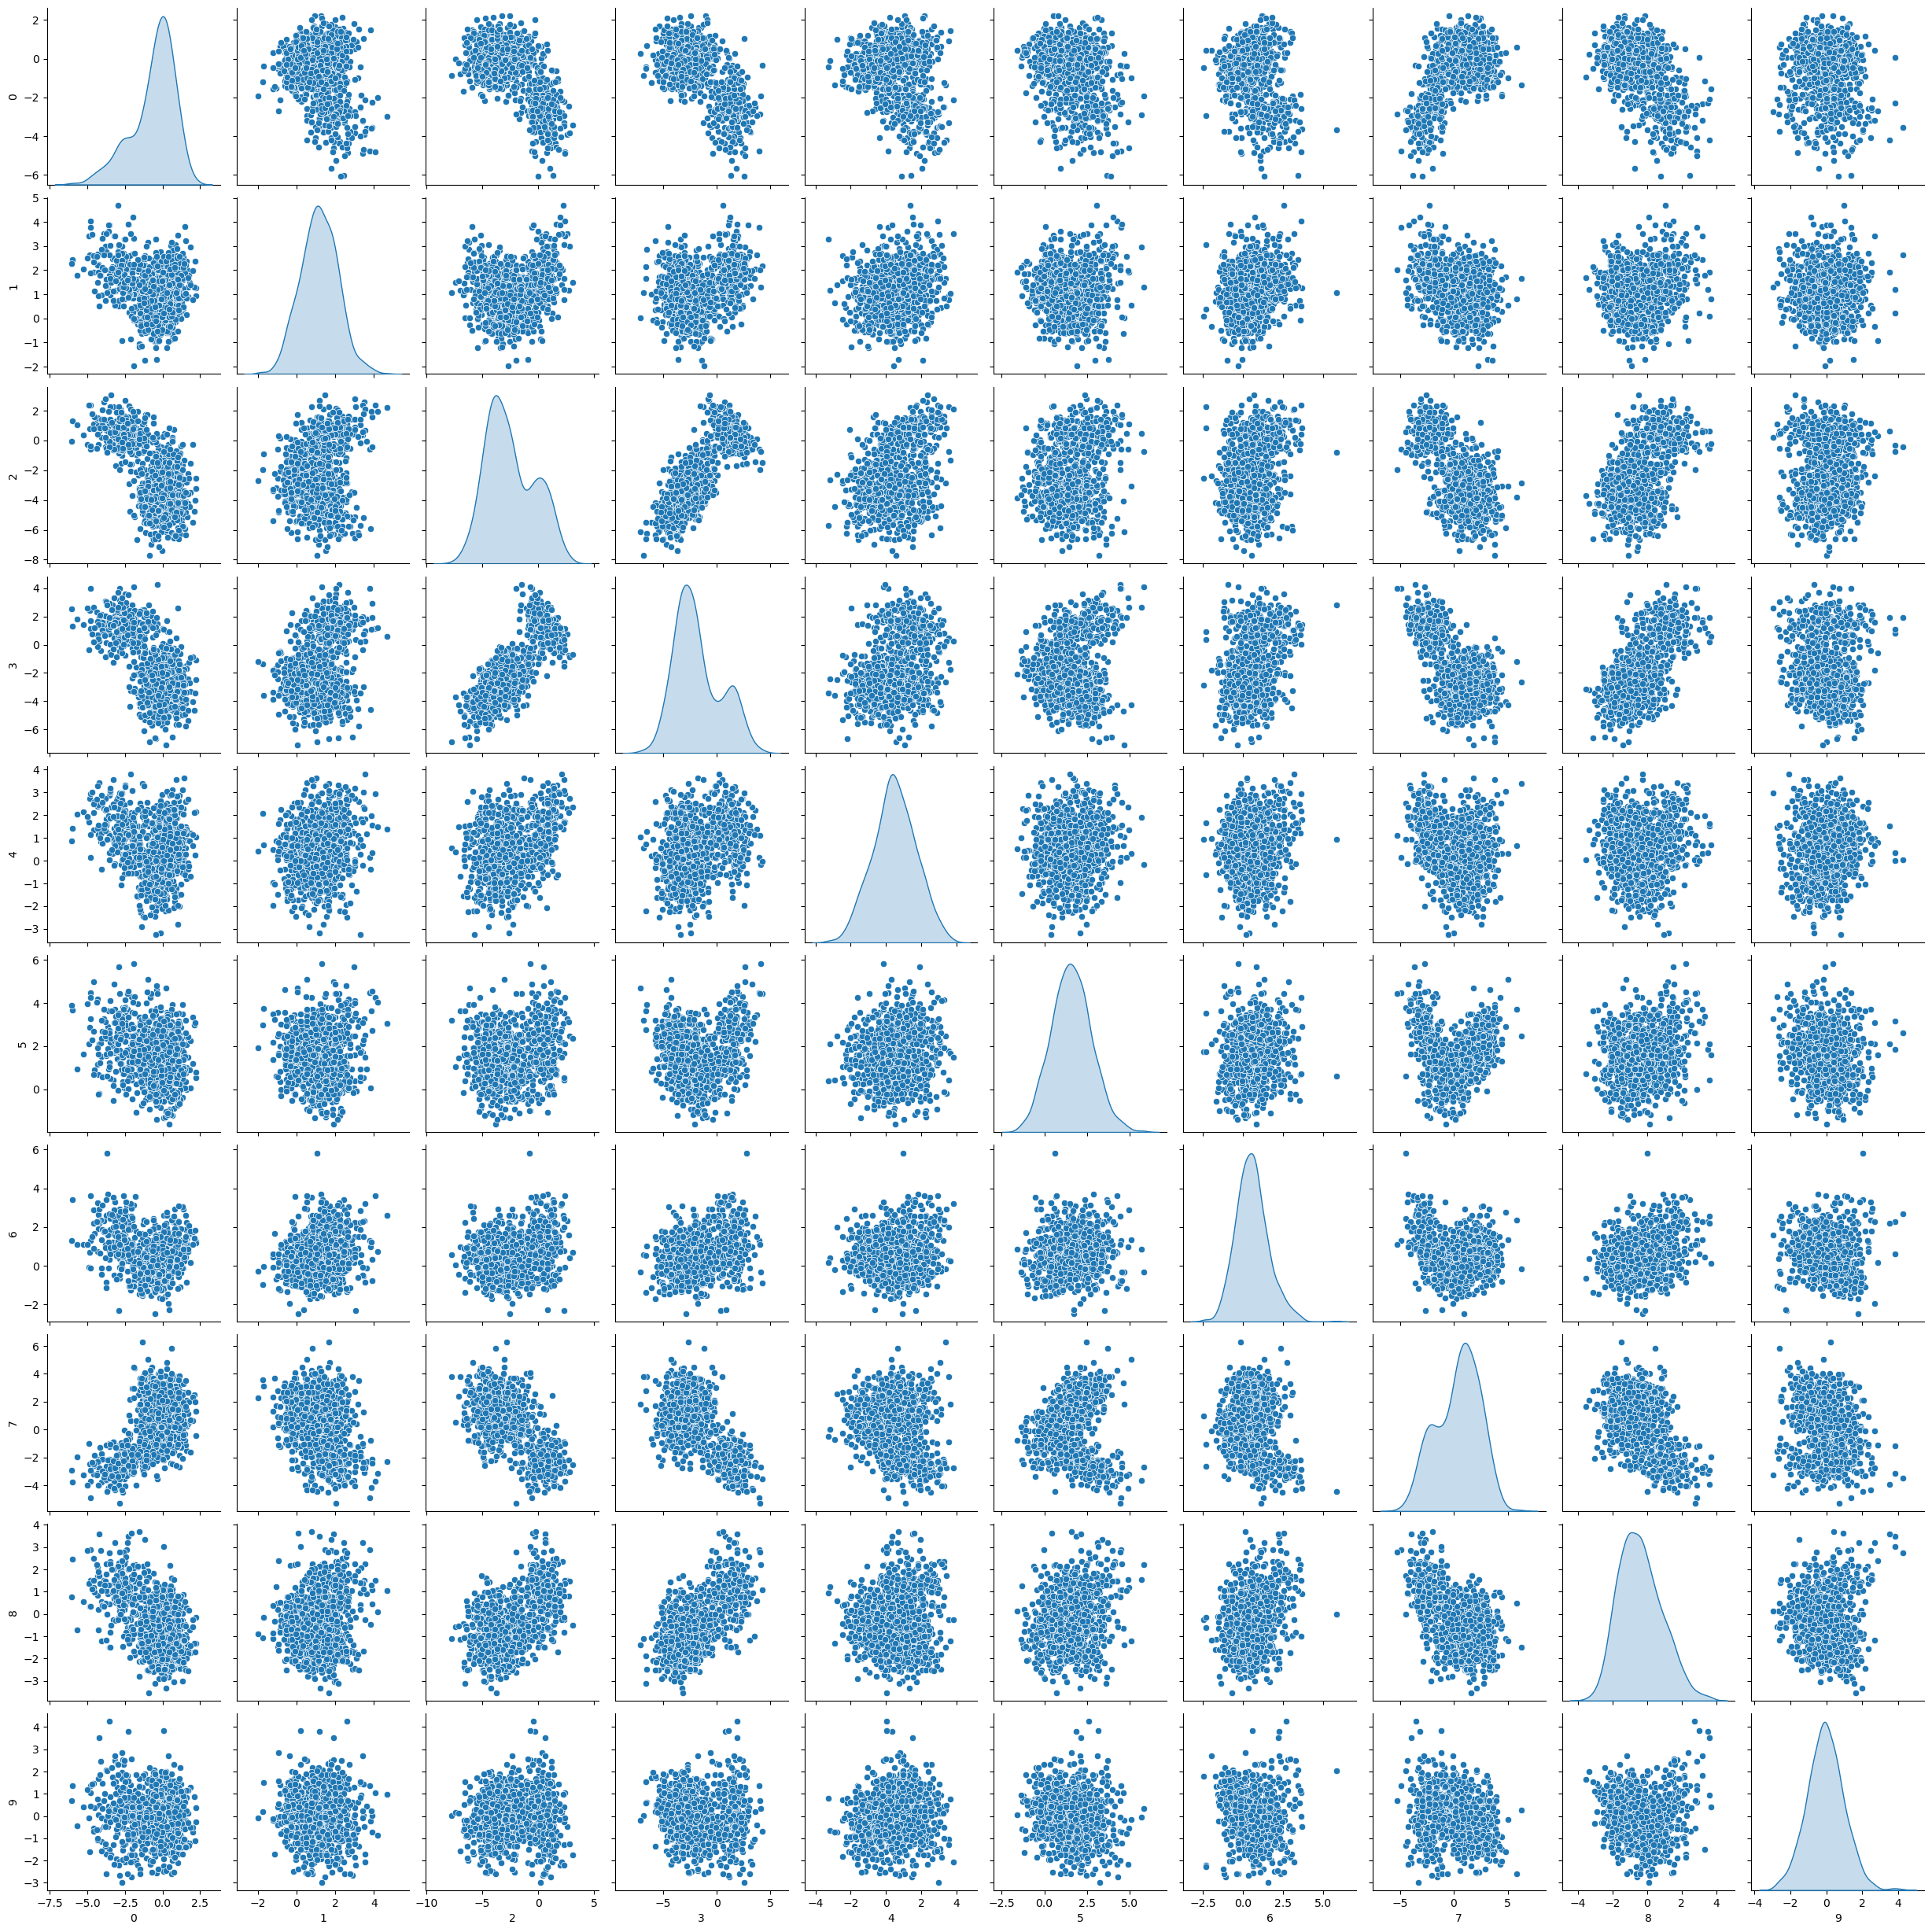

In [55]:
import seaborn as sns
sns.pairplot(dfX, diag_kind='kde')

In [56]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score

# X, y assumed in memory
X = np.asarray(X)
y = np.asarray(y).ravel()

pipe_lle = Pipeline([
    ("scale", StandardScaler()),
    ("lle", LocallyLinearEmbedding(
        n_neighbors=30,      # tune: ~15-60
        n_components=3,      # tune: 2-6
        method="modified",   # usually more stable than "standard"
        random_state=7
    )),
    ("reg", Ridge(alpha=1.0)),
])

cv = KFold(n_splits=5, shuffle=True, random_state=7)
r2 = cross_val_score(pipe_lle, X, y, cv=cv, scoring="r2")
print("LLE+Ridge CV R2:", np.round(r2, 4), "mean=", round(r2.mean(), 4))


LLE+Ridge CV R2: [ 0.0006 -0.0003  0.0004  0.0004 -0.0011] mean= -0.0


In [64]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import HuberRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score

# X, y assumed in memory
X = np.asarray(X)
y = np.asarray(y).ravel()

pipe_huber = Pipeline([
    # ("scale", StandardScaler()),
    ("huber", HuberRegressor(
        epsilon=5,      # robustness threshold (try 1.2-2.0)
        alpha=1e-4,        # L2 regularization
        max_iter=1000
    )),
])

cv = KFold(n_splits=5, shuffle=True, random_state=7)
r2_cv = cross_val_score(pipe_huber, X, y, cv=cv, scoring="r2")
print("Huber CV R2:", np.round(r2_cv, 4), "mean=", round(r2_cv.mean(), 4))

# Fit once on full data
pipe_huber.fit(X, y)
y_hat = pipe_huber.predict(X)
print("Huber train R2:", round(r2_score(y, y_hat), 4))


Huber CV R2: [-0.0021 -0.0025 -0.0023 -0.0027 -0.0044] mean= -0.0028
Huber train R2: -0.0


In [121]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

pipe = make_pipeline(
    StandardScaler(),
    KNeighborsRegressor()
)

param_grid = {"kneighborsregressor__n_neighbors": [10, 30, 100]}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = GridSearchCV(pipe, param_grid, cv=cv, scoring="r2", n_jobs=-1)
search.fit(X, y)

print("Best k:", search.best_params_["kneighborsregressor__n_neighbors"])
print("Best CV R2:", round(search.best_score_, 4))


Best k: 30
Best CV R2: 0.0552


In [122]:
print(pipe.get_params().keys())

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'standardscaler', 'kneighborsregressor', 'standardscaler__copy', 'standardscaler__with_mean', 'standardscaler__with_std', 'kneighborsregressor__algorithm', 'kneighborsregressor__leaf_size', 'kneighborsregressor__metric', 'kneighborsregressor__metric_params', 'kneighborsregressor__n_jobs', 'kneighborsregressor__n_neighbors', 'kneighborsregressor__p', 'kneighborsregressor__weights'])


In [65]:
from sklearn.linear_model import (LinearRegression, HuberRegressor,
                              	RANSACRegressor, TheilSenRegressor)


ransac = RANSACRegressor(random_state=42).fit(X, y)
y_hatr = ransac.predict(X)
ransac_coef = ransac.estimator_.coef_
## coef_list.append(["ransac_regression", ransac.estimator_.coef_[0]])
print(ransac_coef)

print("r2:", r2_score(y, y_hatr))

[ 0.83449916 -0.19342123 -0.93544669  1.56452556 -0.39709627  0.14284693
 -0.74814175  0.18013763 -1.89686016 -0.61804953]
r2: -0.39831835185310616


In [73]:
treg = TheilSenRegressor(random_state=42)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
r2_cv = cross_val_score(treg, X, y, cv=cv, scoring='r2')
print("Theil-Sen CV R2:", np.round(r2_cv, 4))

Theil-Sen CV R2: [-0.0133 -0.0089 -0.0136 -0.0172 -0.0145]


In [111]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

# X, y assumed already defined
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

model = make_pipeline(
    StandardScaler(),
    KNeighborsRegressor(n_neighbors=60)
)

model.fit(X_train, y_train)
pred = model.predict(X_test)
print("K3 train R2:", r2_score(y_train, model.predict(X_train)))

print("R2:", r2_score(y_test, pred))


K3 train R2: 0.09052098202451953
R2: 0.05580212853197719


In [90]:
## Coming back to OLS to run diagnostics

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.outliers_influence import OLSInfluence



model =  fit_ols(X, y)
print(model.summary())

# infl = OLSInfluence(model)   # influence / outlier diagnostics
infl = model.get_influence()

fitted = model.fittedvalues
resid = model.resid

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                     0.000
Date:                Mon, 02 Mar 2026   Prob (F-statistic):               1.00
Time:                        22:38:42   Log-Likelihood:                -30767.
No. Observations:               10000   AIC:                         6.156e+04
Df Residuals:                    9989   BIC:                         6.164e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.586e-16      0.148   3.79e-15      1.0

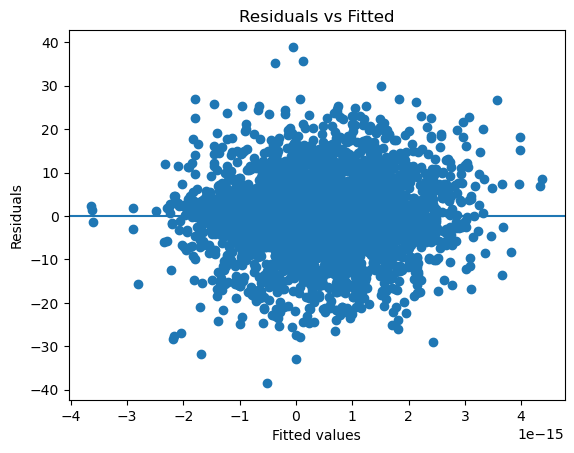

In [91]:
plt.figure()
plt.scatter(fitted, resid)
plt.axhline(0)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()



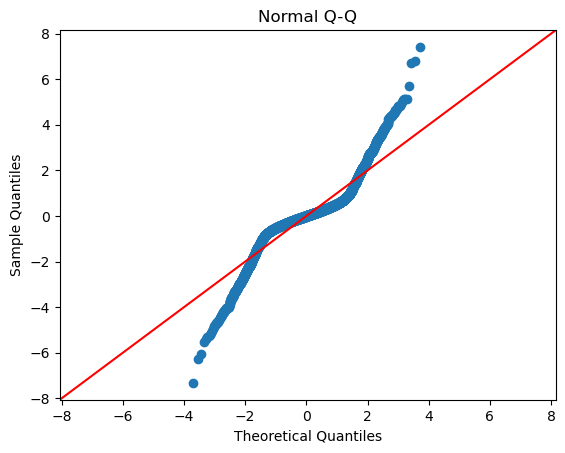

In [92]:
qqplot(resid, line="45", fit=True)
plt.title("Normal Q-Q")
plt.show()

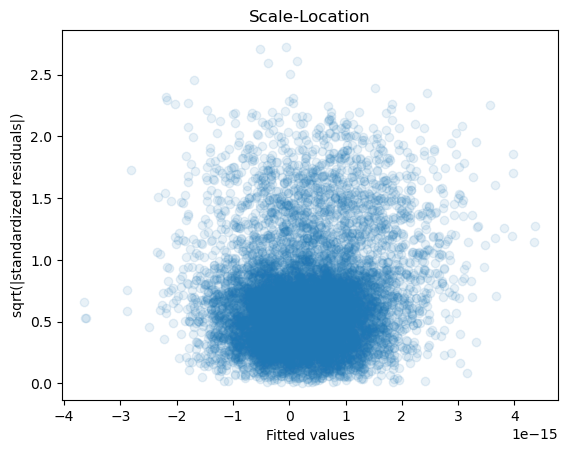

In [124]:
std_resid = infl.resid_studentized_internal
plt.figure()
plt.scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.1)
plt.xlabel("Fitted values")
plt.ylabel("sqrt(|standardized residuals|)")
plt.title("Scale-Location")
plt.show()

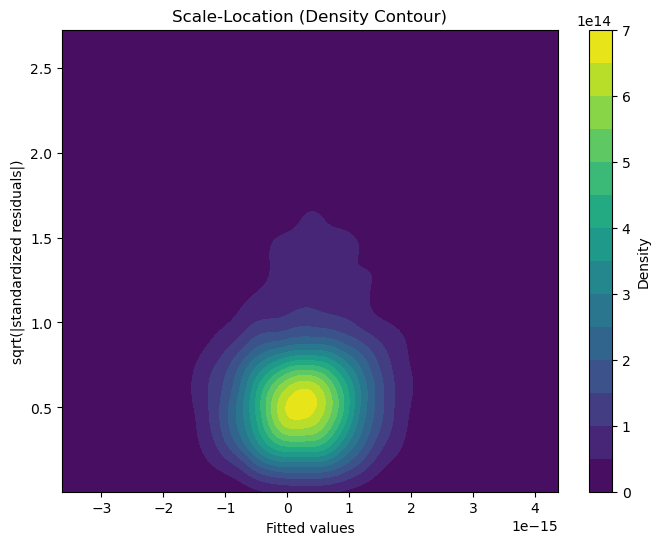

In [125]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

std_resid = infl.resid_studentized_internal
y_vals = np.sqrt(np.abs(std_resid))
x_vals = fitted

# Stack for KDE
values = np.vstack([x_vals, y_vals])
kde = gaussian_kde(values)

# Create grid
x_grid = np.linspace(x_vals.min(), x_vals.max(), 200)
y_grid = np.linspace(y_vals.min(), y_vals.max(), 200)
X, Y = np.meshgrid(x_grid, y_grid)

positions = np.vstack([X.ravel(), Y.ravel()])
Z = np.reshape(kde(positions), X.shape)

# Plot contour
plt.figure(figsize=(8,6))
plt.contourf(X, Y, Z, levels=15)
plt.xlabel("Fitted values")
plt.ylabel("sqrt(|standardized residuals|)")
plt.title("Scale-Location (Density Contour)")
plt.colorbar(label="Density")
plt.show()

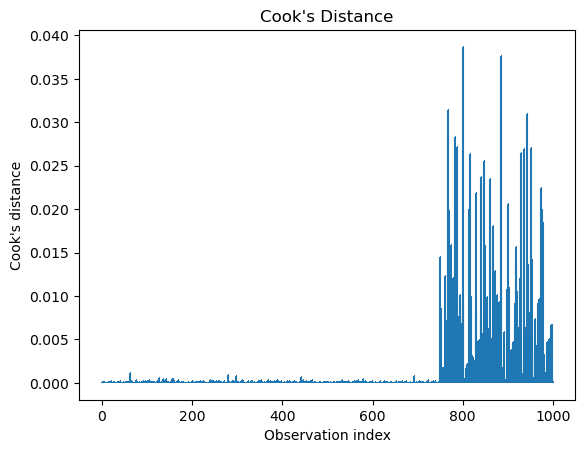

In [112]:
plt.figure()
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",", basefmt=" ")
plt.xlabel("Observation index")
plt.ylabel("Cook's distance")
plt.title("Cook's Distance")
plt.show()

In [113]:
n = X.shape[0]
p = X.shape[1]  # includes intercept

student = infl.resid_studentized_external  # better for outlier detection than internal
leverage = infl.hat_matrix_diag
cooks_d = infl.cooks_distance[0]
dffits, dffits_threshold = infl.dffits
dfbetas = infl.dfbetas

In [119]:
# common thresholds:

outlier_mask = np.abs(student) > 3
high_lev_mask = leverage > (2 * p / n)
cooks_mask = cooks_d > (4 / n)          # sometimes also flag > 1 as "very large"
dffits_mask = np.abs(dffits) > dffits_threshold

In [120]:
sum(outlier_mask), sum(high_lev_mask), sum(cooks_mask), sum(dffits_mask)

(np.int64(272), np.int64(682), np.int64(845), np.int64(845))

In [129]:
leverage.sum()

np.float64(11.0)